In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer


### Load the data and basic overview

* The dataset contains **8469 customer support tickets** along with **17 features**.
* There is significant amount of missing values in which are likely **not data errors instead correlates directly with ticket status**.
* There are about **392 duplicate entries** in ticket description feature
* Highest volume of ticket is tends to be Refund Request 
* **Canon EOS** is the product generating most **support volume**.
* **Email** is most utilised communication channel and most tickets are assigned a **medium priority**.
* The **average satisfaction rating is 3** out of 5, indicates a neutral or mixed customer customer sentiment overall.

In [ ]:
csv_file = Path("../data/customer_support_tickets.csv")
df = pd.read_csv(csv_file)
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [4]:
df.shape

(8469, 17)

In [ ]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [7]:
df.describe()

,Ticket ID,Customer Age,Customer Satisfaction Rating
count,8469.000000,8469.000000,2769.000000
mean,4235.000000,44.026804,2.991333
std,2444.934048,15.296112,1.407016
min,1.000000,18.000000,1.000000
25%,2118.000000,31.000000,2.000000
50%,4235.000000,44.000000,3.000000
75%,6352.000000,57.000000,4.000000
max,8469.000000,70.000000,5.000000


In [8]:
df.describe(include = "all")

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
count,8469.000000,8469,8469,8469.000000,8469,8469,8469,8469,8469,8469,8469,2769,8469,8469,5650,2769,2769.000000
unique,NaN,8028,8320,NaN,3,42,730,5,16,8077,3,2769,4,4,5470,2728,NaN
top,NaN,Michael Garcia,asmith@example.com,NaN,Male,Canon EOS,2020-10-21,Refund request,Refund request,I'm having an issue with the {product_purchase...,Pending Customer Response,We seat culture plan.,Medium,Email,2023-06-01 20:45:39,2023-06-01 17:14:42,NaN
freq,NaN,5,4,NaN,2896,240,24,1752,576,25,2881,1,2192,2143,3,3,NaN
mean,4235.000000,NaN,NaN,44.026804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.991333
std,2444.934048,NaN,NaN,15.296112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.407016
min,1.000000,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
25%,2118.000000,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
50%,4235.000000,NaN,NaN,44.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000
75%,6352.000000,NaN,NaN,57.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000


### Datatype analysis

* Now, the dataset is well structured after datatype conversion with clear separation between numerical, categorical, datetime and text features.
    * **7 categorical features** converted from object type to Category for memory optimisation
    * **3** features parsed into datetime objects
    * **3** numerical features
    * **4** text features

In [9]:
num_cols = df.select_dtypes(include=["float", "int"]).columns
num_cols

Index(['Ticket ID', 'Customer Age', 'Customer Satisfaction Rating'], dtype='object')

In [10]:
obj_cols = df.select_dtypes(include=["object"]).columns
obj_cols

Index(['Customer Name', 'Customer Email', 'Customer Gender',
       'Product Purchased', 'Date of Purchase', 'Ticket Type',
       'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution',
       'Ticket Priority', 'Ticket Channel', 'First Response Time',
       'Time to Resolution'],
      dtype='object')

In [ ]:
text_cols = ['Customer Name', 'Customer Email', 'Ticket Description', 'Resolution']
dt_cols = ['Date of Purchase', 'First Response Time','Time to Resolution']
category_cols = ['Customer Gender', 'Product Purchased', 'Ticket Type', 'Ticket Subject', 'Ticket Status', 'Ticket Priority', 'Ticket Channel']

In [12]:
for col in dt_cols:
    df[col] = pd.to_datetime(df[col])

In [13]:
for col in category_cols:
    df[col] = df[col].astype("category")

In [14]:
# no change in datatype - results
for col in text_cols:
    df[col] = df[col].astype("str")

In [15]:
df.dtypes

Ticket ID                                int64
Customer Name                           object
Customer Email                          object
Customer Age                             int64
Customer Gender                       category
Product Purchased                     category
Date of Purchase                datetime64[ns]
Ticket Type                           category
Ticket Subject                        category
Ticket Description                      object
Ticket Status                         category
Resolution                              object
Ticket Priority                       category
Ticket Channel                        category
First Response Time             datetime64[ns]
Time to Resolution              datetime64[ns]
Customer Satisfaction Rating           float64
dtype: object

### Missing values analysis

* **67% of missing values in Time to Resolution** feature indicates that large number of tickets are unresolved.
* **First Response Time** has fewer missing values of about **33%** comparatively, which depicts that initial responses are recorded for most tickets even if the tickets are not resolved.
* Hence, ongoing or unresolved tickets do not have resolution time or satisfaction ratings.

In [16]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                         0
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [17]:
null_count = df.isnull().sum()
null_count = null_count[null_count > 0]
null_count

First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [18]:
null_percent = (df.isnull().sum() / len(df) * 100).round(0).astype(int)
null_percent = null_percent[null_percent > 0]
null_percent

First Response Time             33
Time to Resolution              67
Customer Satisfaction Rating    67
dtype: int64

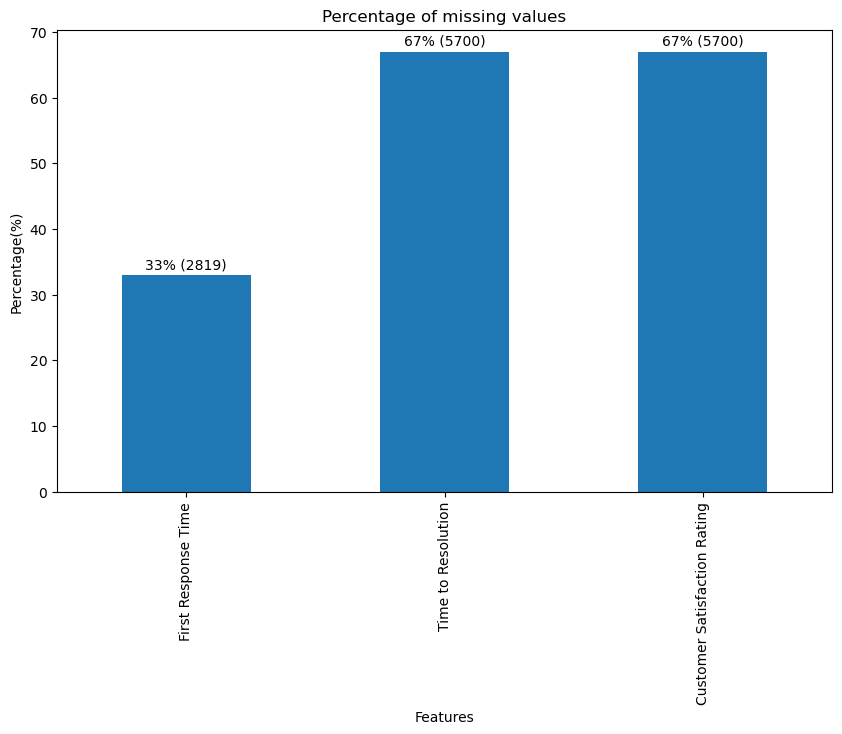

In [19]:
plt.figure(figsize = (10,6))
null_percent.plot(kind="bar")

plt.title("Percentage of missing values")
plt.xlabel("Features")
plt.ylabel("Percentage(%)")

for i,j in enumerate(null_percent):
    plt.text(i, j+1, str(j)+"% "+f"({null_count.iloc[i]})", ha = "center")



### Data distribution analysis

In [20]:
category_cols

['Customer Gender',
 'Product Purchased',
 'Ticket Type',
 'Ticket Subject',
 'Ticket Status',
 'Ticket Priority',
 'Ticket Channel']

* Distribuion of customer gender is relatively balanced indicating that issues are not strongly skewed towards any specific gender group

In [21]:
cust_gender_dist = df["Customer Gender"].value_counts()
cust_gender_dist

Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64

Text(0.5, 1.0, 'Customer Gender distribution')

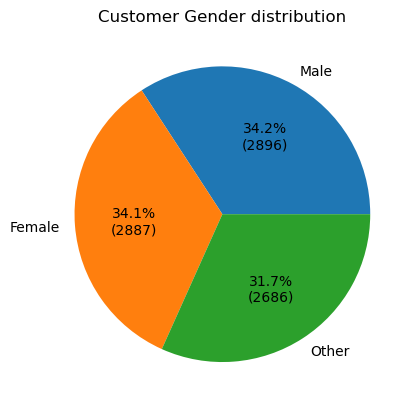

In [22]:
plt.pie(cust_gender_dist, labels=cust_gender_dist.index, 
        autopct = lambda pct: f"{pct:.1f}%\n({int(round(pct * sum(cust_gender_dist) / 100))})")

plt.title("Customer Gender distribution")

* Distribution of products purchased is fairly uniform across wide range of items with no single product dominating
* Products like Canon EOS, GoPro Hero, Nest Thermostat tends to appear more frequently which indicate either a higher sales volume or greater tendency for issues associated with these.

In [23]:
prod_purchased_dist = df["Product Purchased"].value_counts().sort_values()
prod_purchased_dist

Product Purchased
Nintendo Switch                   178
Adobe Photoshop                   181
GoPro Action Camera               183
Lenovo ThinkPad                   183
Dell XPS                          185
MacBook Pro                       186
Asus ROG                          187
Xbox                              187
Samsung Soundbar                  188
Microsoft Surface                 190
Bose QuietComfort                 190
Fitbit Versa Smartwatch           191
PlayStation                       192
Samsung Galaxy                    194
Microsoft Xbox Controller         196
Autodesk AutoCAD                  196
Bose SoundLink Speaker            197
Amazon Kindle                     198
Google Nest                       198
Dyson Vacuum Cleaner              198
HP Pavilion                       200
Microsoft Office                  200
Fitbit Charge                     202
Sony PlayStation                  202
Nintendo Switch Pro Controller    203
Google Pixel                    

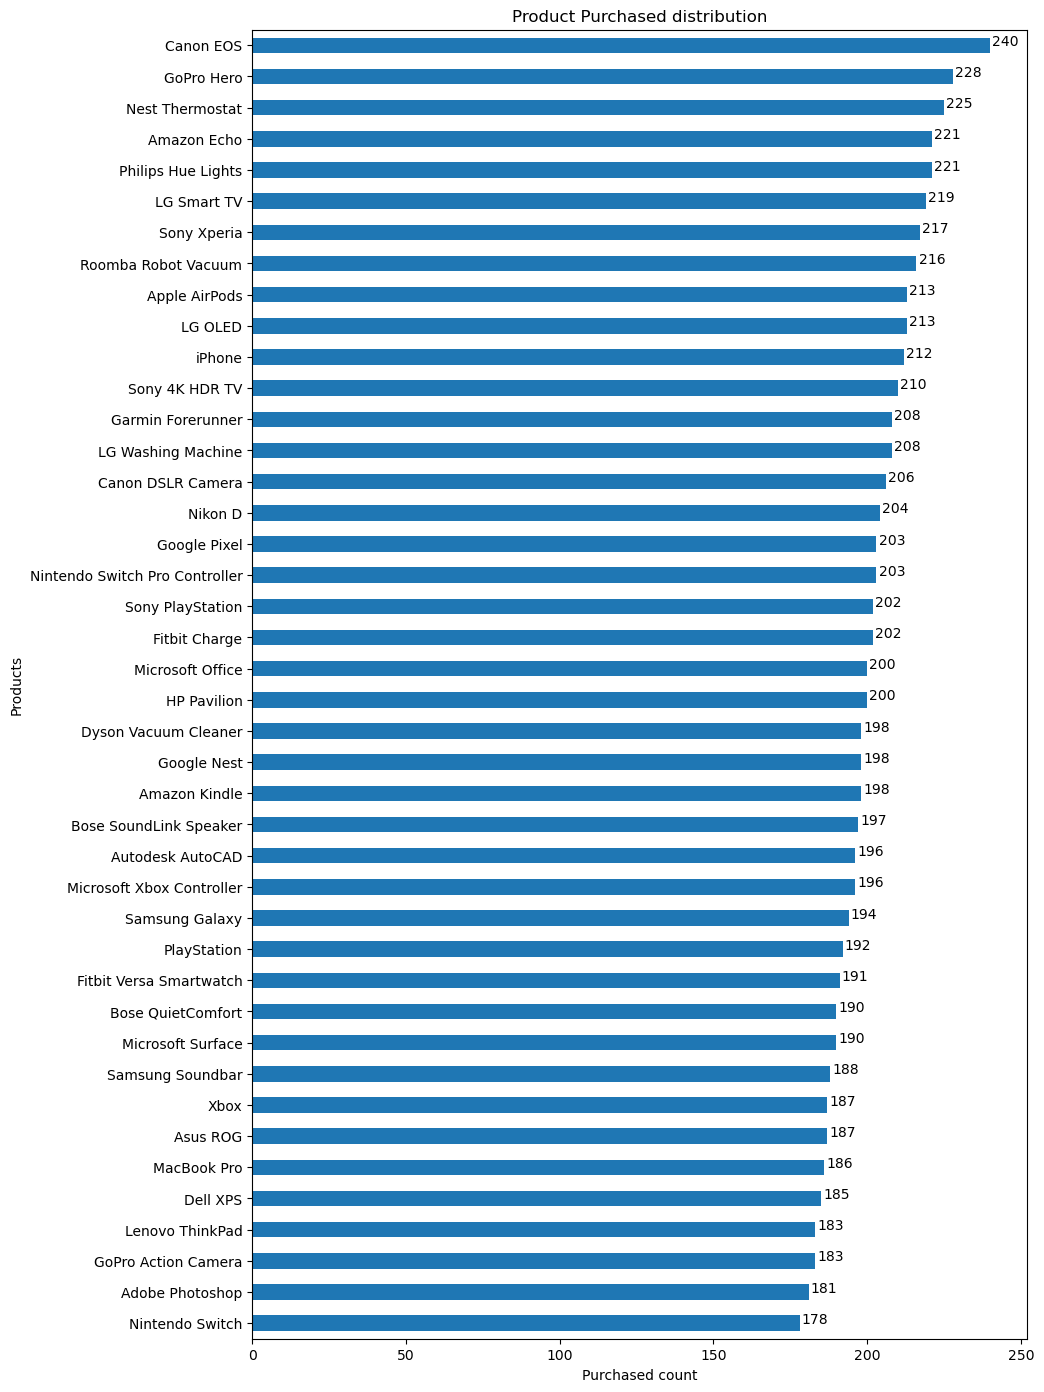

In [24]:
plt.figure(figsize = (10,17))
prod_purchased_dist.plot(kind="barh")

plt.title("Product Purchased distribution")
plt.ylabel("Products")
plt.xlabel("Purchased count")

for i,j in enumerate(prod_purchased_dist):
    plt.text(j+5, i, f"{prod_purchased_dist.iloc[i]}", ha = "center")



* Ticket types are evenly distributed with refund requests and technical issues at the top 

In [25]:
ticket_type_dist = df["Ticket Type"].value_counts()
ticket_type_dist

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Text(0.5, 1.0, 'Ticket type distribution')

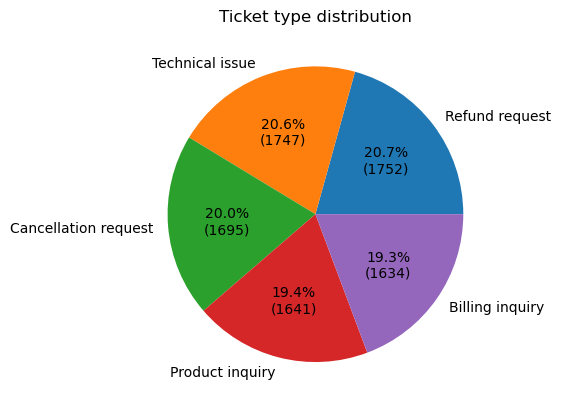

In [26]:
plt.pie(ticket_type_dist, labels=ticket_type_dist.index, 
        autopct = lambda pct: f"{pct:.1f}%\n({int(round(pct * sum(ticket_type_dist) / 100))})")

plt.title("Ticket type distribution")

* Ticket subjects show a diverse range of specific issues with categories like refund request, software bug, product compatibility appearing frequently.
* This suggests that customer concerns span multiple dimensions which gives the need for clustering techniques to group related issues effectively.

In [27]:
ticket_subject_dist = df["Ticket Subject"].value_counts()
ticket_subject_dist

Ticket Subject
Refund request              576
Software bug                574
Product compatibility       567
Delivery problem            561
Hardware issue              547
Battery life                542
Network problem             539
Installation support        530
Product setup               529
Payment issue               526
Product recommendation      517
Account access              509
Peripheral compatibility    496
Data loss                   491
Cancellation request        487
Display issue               478
Name: count, dtype: int64

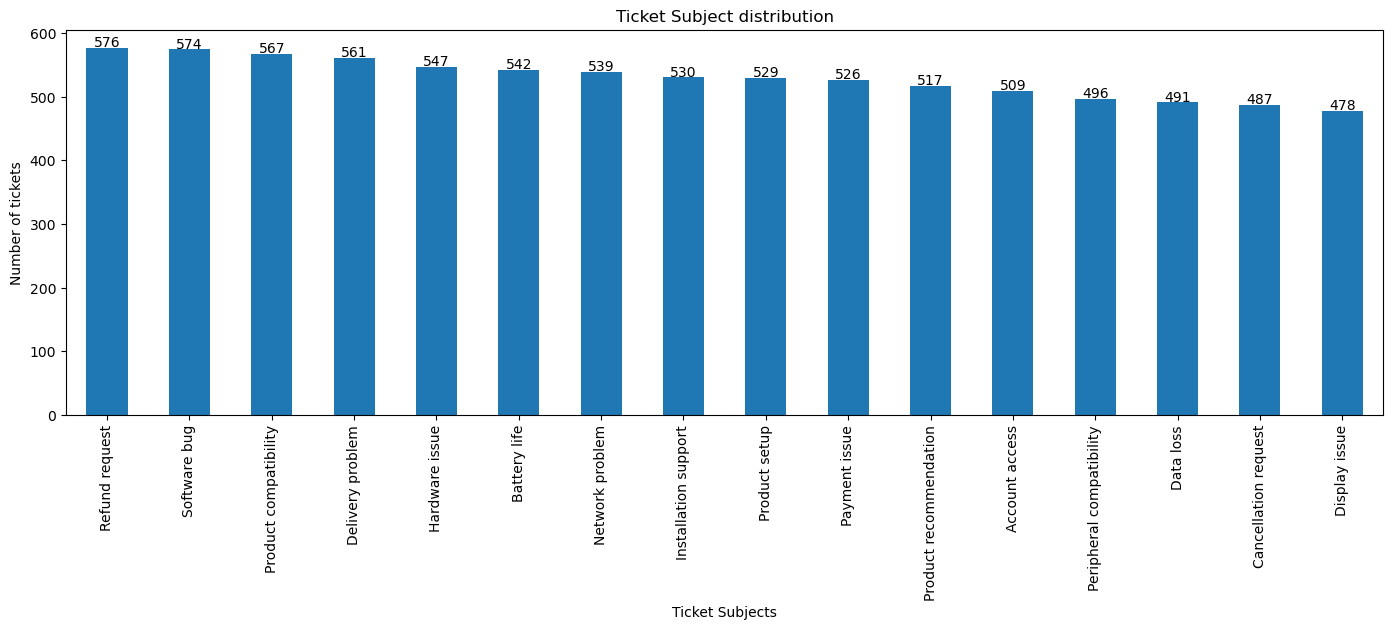

In [28]:
plt.figure(figsize = (17, 5))
ticket_subject_dist.plot(kind="bar")

plt.title("Ticket Subject distribution")
plt.ylabel("Number of tickets")
plt.xlabel("Ticket Subjects")

for i,j in enumerate(ticket_subject_dist):
    plt.text(i, j+2, f"{ticket_subject_dist.iloc[i]}", ha = "center")



* Significant proportion of ticket status is in pending customer response state which indiactaes a potential delays in resolution workflow.

In [29]:
ticket_status_dist = df["Ticket Status"].value_counts()
ticket_status_dist

Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

Text(0.5, 1.0, 'Ticket status distribution')

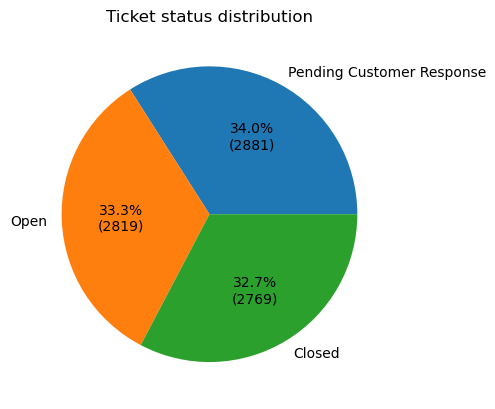

In [30]:
plt.pie(ticket_status_dist, labels=ticket_status_dist.index, 
        autopct = lambda pct: f"{pct:.1f}%\n({int(round(pct * sum(ticket_status_dist) / 100))})")

plt.title("Ticket status distribution")

* Ticket priority is centers around medium level issues

In [31]:
ticket_priority_dist = df["Ticket Priority"].value_counts()
ticket_priority_dist

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

Text(0.5, 1.0, 'Ticket priority distribution')

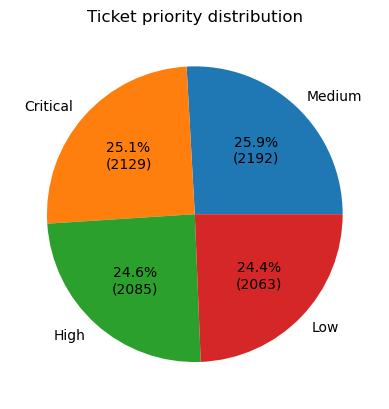

In [32]:
plt.pie(ticket_priority_dist, labels=ticket_priority_dist.index, 
        autopct = lambda pct: f"{pct:.1f}%\n({int(round(pct * sum(ticket_priority_dist) / 100))})")

plt.title("Ticket priority distribution")

* Customer support interactions are evely distributed across communication channels, where email slighly being dominant.

In [33]:
ticket_channel_dist = df["Ticket Channel"].value_counts()
ticket_channel_dist

Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64

Text(0.5, 1.0, 'Ticket channel distribution')

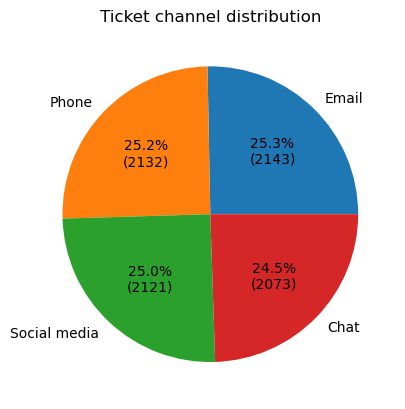

In [34]:
plt.pie(ticket_channel_dist, labels=ticket_channel_dist.index, 
        autopct = lambda pct: f"{pct:.1f}%\n({int(round(pct * sum(ticket_channel_dist) / 100))})")

plt.title("Ticket channel distribution")

### Numerical column analysis

* The mean (44.02) and median (44) are identical which indicates zero skewness in the data
* Histogram shows a highly even spread across all age groups ranging from 18 to 70.

In [123]:
# 3 numerical columns

num_cols

Index(['Ticket ID', 'Customer Age', 'Customer Satisfaction Rating'], dtype='object')

In [122]:
df['Customer Age'].describe()

count    8469.000000
mean       44.026804
std        15.296112
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Customer Age, dtype: float64

In [ ]:
# Mean of "Customer Age" feature is 44

cust_age_mean = df["Customer Age"].mean().round(0).astype(int)
cust_age_mean

np.int64(44)

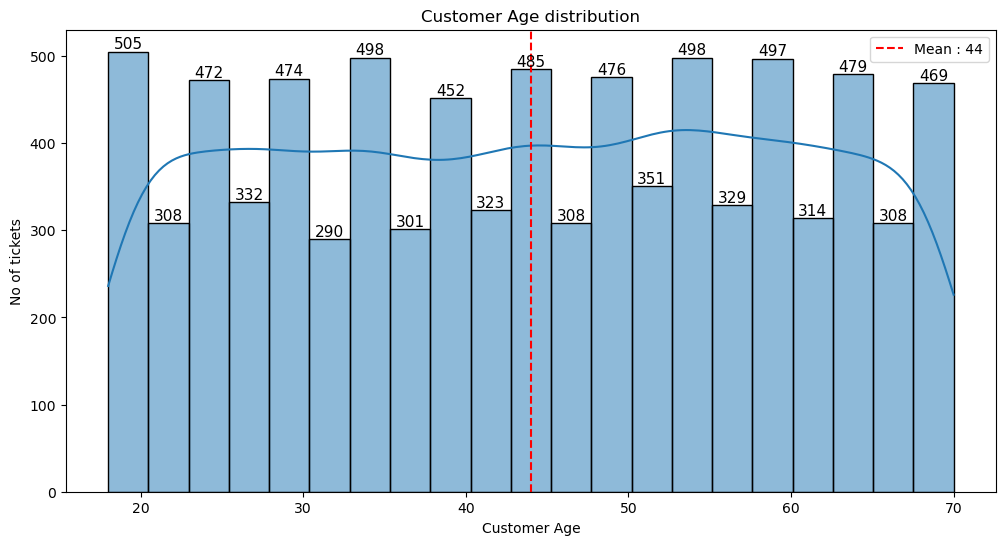

In [ ]:
# Plot age distribution with mean to understang customer demographics

plt.figure(figsize= (12,6))
age_dist = sns.histplot(df['Customer Age'], bins = 'auto', kde = True)

# Add count labels on top of bars
age_dist.bar_label(age_dist.containers[0], fontsize = 11)
plt.title("Customer Age distribution")
plt.ylabel("No of tickets")

# Highlight mean age to show central tendency
plt.axvline(cust_age_mean, color = 'r', linestyle='--', label = f"Mean : {cust_age_mean}")

plt.legend()


In [ ]:
# Bin customer age into 21 intervals to analyse distribution

df["Customer Age"].value_counts(bins = 21)

(17.947, 20.476]    505
(52.667, 55.143]    498
(32.857, 35.333]    498
(57.619, 60.095]    497
(42.762, 45.238]    485
(62.571, 65.048]    479
(47.714, 50.19]     476
(27.905, 30.381]    474
(22.952, 25.429]    472
(67.524, 70.0]      469
(37.81, 40.286]     452
(50.19, 52.667]     351
(25.429, 27.905]    332
(55.143, 57.619]    329
(40.286, 42.762]    323
(60.095, 62.571]    314
(20.476, 22.952]    308
(45.238, 47.714]    308
(65.048, 67.524]    308
(35.333, 37.81]     301
(30.381, 32.857]    290
Name: count, dtype: int64

Text(0.5, 1.0, 'Customer Satisfaction Rating distribution')

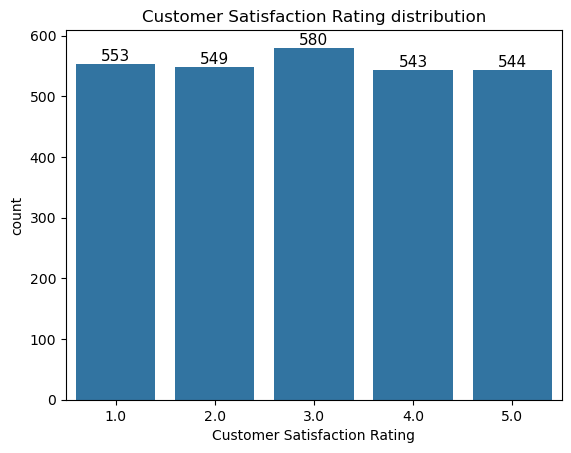

In [ ]:
# visualise distribution of customer satisfaction ratings

rating_dist = sns.countplot(data = df, x = "Customer Satisfaction Rating")
rating_dist.bar_label(rating_dist.containers[0], fontsize = 11)
plt.title("Customer Satisfaction Rating distribution")

In [ ]:
df["Customer Satisfaction Rating"].value_counts()

Customer Satisfaction Rating
3.0    580
1.0    553
2.0    549
5.0    544
4.0    543
Name: count, dtype: int64

### Temporal trends analysis

* Out of 2769 resolved tickets, 1365 tickets contain a logical impossibility i.e., Time to Resolution is before the first response time.

In [45]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,nan,Critical,Social media,2023-06-01 12:15:36,NaT,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,nan,Critical,Chat,2023-06-01 16:45:38,NaT,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [46]:
purchase_year = df["Date of Purchase"].dt.year
purchase_month_year = df['Date of Purchase'].dt.to_period('M')

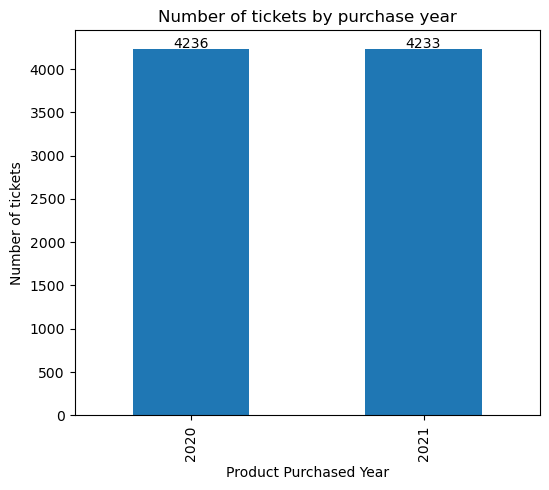

In [ ]:
# Plot to visualise ticket volume across years

plt.figure(figsize= (6,5))

purchase_year_trend = purchase_year.value_counts()
purchase_year_trend.plot(kind='bar')

plt.title("Number of tickets by purchase year")
plt.ylabel("Number of tickets")
plt.xlabel("Product Purchased Year")

for i,j in enumerate(purchase_year_trend):
    plt.text(i, j+5, f"{purchase_year_trend.iloc[i]}", ha = "center")

In [124]:
purchase_yearmonth_trend = purchase_month_year.value_counts().sort_index()
purchase_yearmonth_trend

Date of Purchase
2020-01    377
2020-02    376
2020-03    324
2020-04    354
2020-05    322
2020-06    358
2020-07    366
2020-08    327
2020-09    369
2020-10    373
2020-11    340
2020-12    350
2021-01    359
2021-02    339
2021-03    348
2021-04    364
2021-05    379
2021-06    320
2021-07    361
2021-08    364
2021-09    327
2021-10    362
2021-11    364
2021-12    346
Freq: M, Name: count, dtype: int64

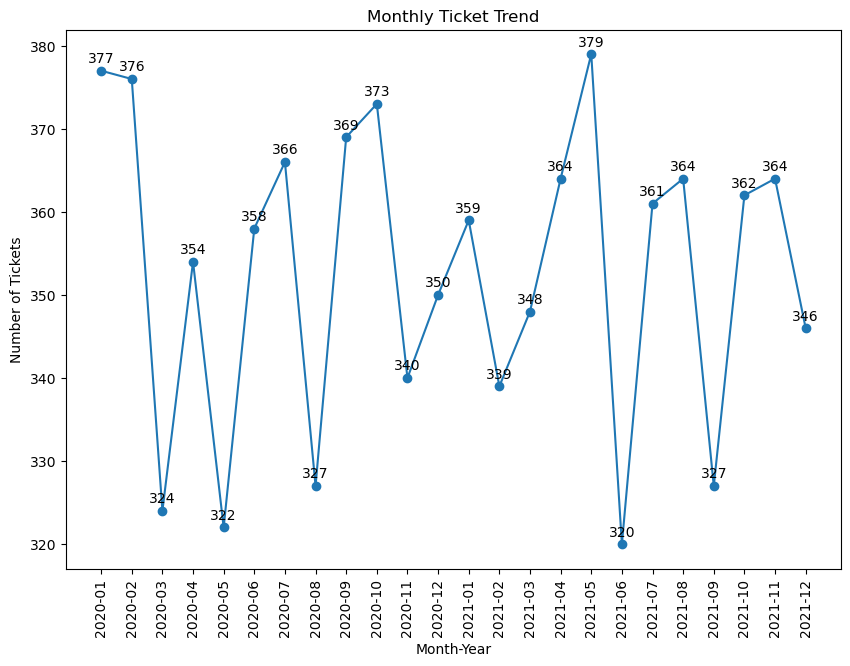

In [125]:
# Plot monthly ticket trend to understand seasonality in ticket volume

plt.figure(figsize=(10,7))

x_vals = purchase_yearmonth_trend.index.astype(str)
y_vals = purchase_yearmonth_trend.values

plt.plot(x_vals, y_vals, marker='o')

for i, y in enumerate(y_vals):
    plt.text(i, y + 1, str(y), ha='center')

plt.xticks(rotation=90)
plt.title("Monthly Ticket Trend")
plt.xlabel("Month-Year")
plt.ylabel("Number of Tickets")

plt.show()

In [52]:
# equals to closed tickets

tickets_resolved = (df['First Response Time'].notnull() & df["Time to Resolution"].notnull())
total_tickets_resolved = tickets_resolved.sum()
total_tickets_resolved

np.int64(2769)

In [ ]:
# not possible scenario - ticket resolved time is less than first response time

resolve_time_anomaly = df.loc[tickets_resolved, "Time to Resolution"] < df.loc[tickets_resolved, "First Response Time"]
resolve_time_anomaly.sum()

np.int64(1365)

In [54]:
total_tickets_resolved - resolve_time_anomaly.sum()

np.int64(1404)

In [55]:
# need to figure out how to handle this

### Bivariate Analysis

In [59]:
df.groupby("Ticket Priority")["Customer Satisfaction Rating"].mean().round(2)

C:\Users\Saranya\AppData\Local\Temp\ipykernel_14364\2067690111.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Ticket Priority")["Customer Satisfaction Rating"].mean().round(2)


Ticket Priority
Critical    2.96
High        2.98
Low         3.05
Medium      2.98
Name: Customer Satisfaction Rating, dtype: float64

In [60]:
df.groupby("Ticket Channel")["Customer Satisfaction Rating"].mean()

C:\Users\Saranya\AppData\Local\Temp\ipykernel_14364\3504019766.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Ticket Channel")["Customer Satisfaction Rating"].mean()


Ticket Channel
Chat            3.083086
Email           2.963889
Phone           2.952243
Social media    2.969298
Name: Customer Satisfaction Rating, dtype: float64

In [61]:
df.groupby("Ticket Type")["Customer Satisfaction Rating"].mean()

C:\Users\Saranya\AppData\Local\Temp\ipykernel_14364\903285431.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Ticket Type")["Customer Satisfaction Rating"].mean()


Ticket Type
Billing inquiry         3.027574
Cancellation request    3.029070
Product inquiry         3.016886
Refund request          2.934564
Technical issue         2.958621
Name: Customer Satisfaction Rating, dtype: float64

In [62]:
ticket_type_priority = pd.crosstab(df["Ticket Type"], df["Ticket Priority"])
ticket_type_priority

Ticket Priority,Critical,High,Low,Medium
Ticket Type,,,,
Billing inquiry,420,382,398,434
Cancellation request,423,398,414,460
Product inquiry,403,399,398,441
Refund request,444,448,440,420
Technical issue,439,458,413,437


<Axes: xlabel='Ticket Priority', ylabel='Ticket Type'>

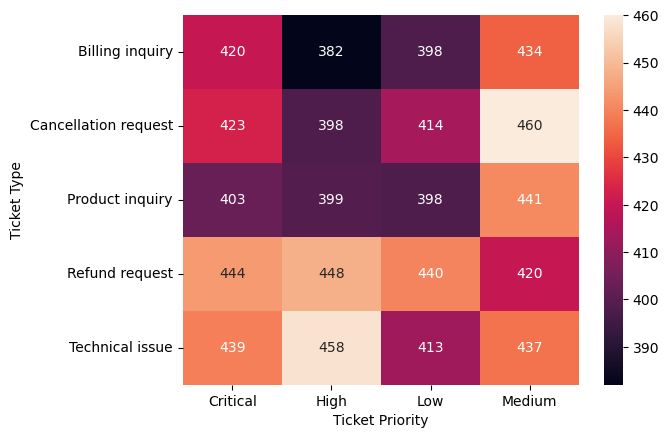

In [63]:
sns.heatmap(ticket_type_priority, annot = True, fmt = "d")

In [64]:
df.groupby("Ticket Priority")["Customer Age"].mean().round(2)

C:\Users\Saranya\AppData\Local\Temp\ipykernel_14364\2063533686.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Ticket Priority")["Customer Age"].mean().round(2)


Ticket Priority
Critical    44.26
High        43.87
Low         43.94
Medium      44.03
Name: Customer Age, dtype: float64

In [65]:
# skip multivariatte analysis as it is aleady uniformly distributed - zero corr

### Ticket Description Analysis

In [66]:
df["Ticket Description"].duplicated().sum()

np.int64(392)

* Drop duplicate rows keeping the first occurence

In [67]:
df_descr = df.drop_duplicates(subset=['Ticket Description'], keep='first').copy()

In [93]:
df_descr.reset_index(drop=True, inplace=True)

In [94]:
df_descr

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Ticket Description charlength,Ticket Description wordlength
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,"I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nYour billing zip code is: 71701.\r\n\r\nWe appreciate that you have requested a website address.\r\n\r\nPlease double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.",Pending Customer Response,nan,Critical,Social media,2023-06-01 12:15:36,NaT,NaN,290,43
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,"I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf you need to change an existing product.\r\n\r\nI'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.",Pending Customer Response,nan,Critical,Chat,2023-06-01 16:45:38,NaT,NaN,288,44
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,"I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.\r\n\r\n1.8.3 I really I'm using the original charger that came with my {product_purchased}, but it's not charging properly.",Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,277,42
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,"I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf you have a problem you're interested in and I'd love to see this happen, please check out the Feedback. I've already contacted customer support multiple times, but the issue remains unresolved.",Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,264,41
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchased}. Please assist.\r\n\r\n\r\nNote: The seller is not responsible for any damages arising out of the delivery of the battleground game. Please have the game in good condition and shipped to you I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,336,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8072,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,"My {product_purchased} is making strange noises and not functioning properly. I suspect there might be a hardware issue. Can you please help me with this?\r\n\r\nAs always, you can email me at support@laserprint. I need assistance as soon as possible because it's affecting my work and productivity.",Open,nan,Low,Phone,NaT,NaT,NaN,295,47
8073,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,"I'm having an issue with the {product_purchased}. Please assist.\r\n\r\n\r\nSell for 30-35% (I also bought a 2.5mm and I'm getting stuck).\r\n\r\n\r\nBuy for 80-100% ( The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.",Open,nan,Critical,Email,NaT,NaT,NaN,259,42
8074,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,"I'm having an issu

In [95]:
df_descr.shape

(8077, 19)

In [96]:
df_descr["Ticket Description charlength"] = df_descr["Ticket Description"].apply(len) 
df_descr["Ticket Description wordlength"] = df_descr["Ticket Description"].str.split().apply(len) 

In [97]:
# almost every descr is same length , symmetrically distributed

df_descr["Ticket Description charlength"].describe()

count    8077.000000
mean      297.943667
std        35.615735
min       151.000000
25%       281.000000
50%       302.000000
75%       321.000000
max       397.000000
Name: Ticket Description charlength, dtype: float64

<Axes: >

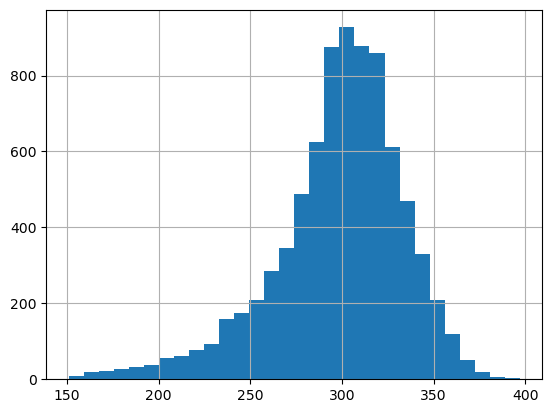

In [98]:
df_descr["Ticket Description charlength"].hist(bins=30)

In [99]:
df_descr["Ticket Description wordlength"].describe()

count    8077.000000
mean       47.436796
std         7.320994
min        21.000000
25%        44.000000
50%        49.000000
75%        53.000000
max        63.000000
Name: Ticket Description wordlength, dtype: float64

<Axes: >

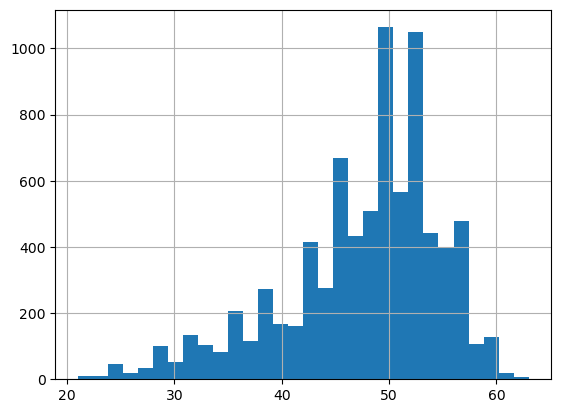

In [100]:
df_descr["Ticket Description wordlength"].hist(bins=30)

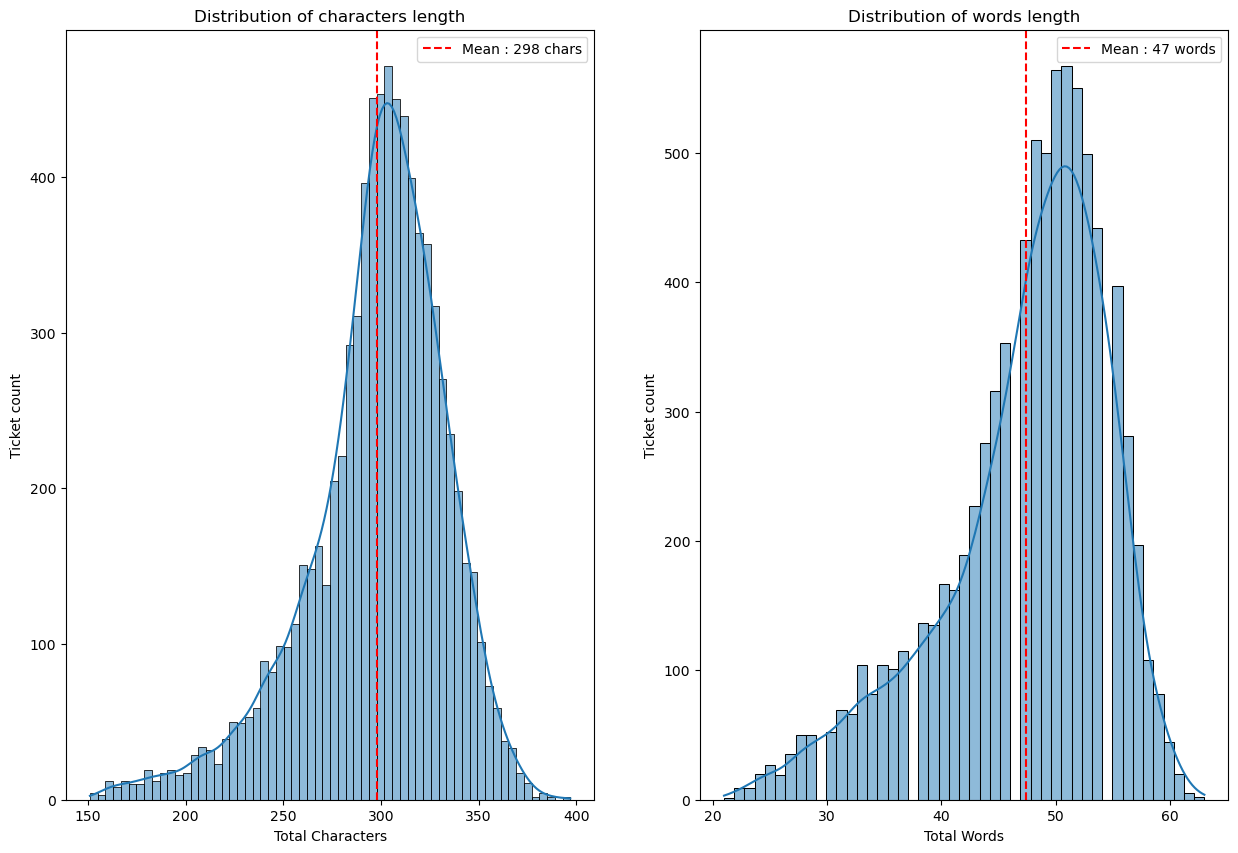

In [101]:
fig1, axes1 = plt.subplots(nrows = 1, ncols = 2, figsize = (15,10))

sns.histplot(df_descr['Ticket Description charlength'], bins='auto', ax = axes1[0], kde = True)
axes1[0].set_title("Distribution of characters length")
axes1[0].set_xlabel('Total Characters')
axes1[0].set_ylabel('Ticket count')

char_mean = df_descr['Ticket Description charlength'].mean()
axes1[0].axvline(char_mean, color = 'red', linestyle='--', label = f"Mean : {char_mean:.0f} chars")
axes1[0].legend()

sns.histplot(df_descr['Ticket Description wordlength'], bins='auto', ax = axes1[1], kde = True)
axes1[1].set_title("Distribution of words length")
axes1[1].set_xlabel('Total Words')
axes1[1].set_ylabel('Ticket count')

word_mean = df_descr['Ticket Description wordlength'].mean()
axes1[1].axvline(word_mean, color = 'red', linestyle='--', label = f"Mean : {word_mean:.0f} words")
axes1[1].legend()

plt.show()


In [102]:
pd.set_option('display.max_colwidth', None)

In [103]:
df_descr["Ticket Description"]

0                                               I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nYour billing zip code is: 71701.\r\n\r\nWe appreciate that you have requested a website address.\r\n\r\nPlease double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.
1                                                 I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf you need to change an existing product.\r\n\r\nI'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.
2                                                                    I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.\r\n\r\n1.8.3 I really I'm using the original charger that came with my 

In [104]:
# checking for placeholders

df_descr['Ticket Description'].str.extractall(r'(\{.*?\})')[0].value_counts()

0
{product_purchased}            13104
{error_message}                  448
{product_id}                      48
{product_name}                    32
{Product_purchased}               18
                               ...  
{Product-Type}                     1
{ p, product }                     1
{ product }                        1
{product_purchased = false}        1
{product_purchased_2}              1
Name: count, Length: 406, dtype: int64

In [119]:
# checking for square brackets

df_descr['Ticket Description'].str.extractall(r'(\[.*?\])')[0].value_counts()

0
[email protected]        43
[Client thread/INFO]     21
[1]                      17
[CHAT]                   14
[0]                      13
                         ..
[37]                      1
[product_packagingId]     1
[0.0.1]                   1
[Edit]                    1
[0 or 1]                  1
Name: count, Length: 388, dtype: int64

In [ ]:
# check for angle brackets

df_descr['Ticket Description'].str.extractall(r'(\<.*?\>)')[0].value_counts()

0
<p>                                      22
<br />                                   22
</div>                                   18
<b>                                      15
</p>                                     14
                                         ..
<tr >                                     1
<div >                                    1
<@sad_finn>                               1
<span className="purchasing_details">     1
</product_purchased>                      1
Name: count, Length: 230, dtype: int64

In [ ]:
# checking for parenthesis

df_descr['Ticket Description'].str.extractall(r'(\(.*?\))')[0].value_counts()

0
()                                          22
(s)                                         14
(1)                                         13
(2)                                         10
(4)                                          7
                                            ..
(In Effect since March 1st of this year)     1
(@m_geogar)                                  1
(Gio)                                        1
(not already installed)                      1
( )                                          1
Name: count, Length: 538, dtype: int64

In [108]:
df_descr['Ticket Description'].iloc[62]

"I'm having an issue with the {product_purchased}. Please assist.\r\n\r\n}\r\n\r\n} }\r\n\r\nfunction getProductCount () {orters(function ($p ) { // This gets the count for all the items in the The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly."

In [ ]:
# checking for url's

df_descr['Ticket Description'].str.extractall(r'(https?://\S+|www\.\S+)')[0].value_counts()

0
https://www                                                             3
http://www.                                                             2
www.bethn.io                                                            2
https://forum.ejconop                                                   1
https://www.wizards.com/en-US/Product/World/The-Oblivion.pau/Product    1
                                                                       ..
http://www.facebook.com/support)                                        1
https://support.apple.com/kb/HT20                                       1
https://t.co/rEzVX0gXmF                                                 1
https://www.donatetogeorge.com                                          1
https://mikesaurio.com/products/chimera-dive-savage/                    1
Name: count, Length: 252, dtype: int64

In [ ]:
# checking for email ids

df_descr['Ticket Description'].str.extractall(r'([a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+)')[0].value_counts()

0
info@sugarbeer.com           2
support@mycologne.com        2
support@crowdfunding.com.    1
information@tacom.com.       1
customer@julietr.com         1
                            ..
eepel@bibdsl.co.uk.          1
sales@kotaku.com.            1
support@tasco.com            1
liannekelee@gmail.com.       1
support@jstor.com            1
Name: count, Length: 78, dtype: int64

In [ ]:
# checking for unusual symbols

df_descr['Ticket Description'].str.extractall(r'([^\x00-\x7F]+)')[0].value_counts()

0
•           113
—            82
             22
–            17
·             6
…             6
©             4
®             2
£             2
」             2
″             2
《             2
》             2
】             1
【             1
™™            1
§             1
↑             1
██            1
🙂             1
π             1
™             1
上星            1
สสทีลาาง      1
คมที้ต่�      1
ø             1
»             1
―             1
�醒            1
็家沙           1
超地理伝獣         1
�逓            1
株に出する         1
「�            1
Name: count, dtype: int64

#### unigram

In [112]:
unigram_vectorizer = CountVectorizer(ngram_range=(1,1), stop_words='english', max_features = 20)
unigram_matrix = unigram_vectorizer.fit_transform(df_descr['Ticket Description'])
unigram_vectorizer.vocabulary_

{'having': np.int64(4),
 'issue': np.int64(6),
 'product_purchased': np.int64(11),
 'assist': np.int64(1),
 've': np.int64(19),
 'tried': np.int64(15),
 'steps': np.int64(14),
 'persists': np.int64(8),
 'product': np.int64(10),
 'problem': np.int64(9),
 'using': np.int64(18),
 'noticed': np.int64(7),
 'software': np.int64(13),
 'unable': np.int64(16),
 'account': np.int64(0),
 'resolve': np.int64(12),
 'help': np.int64(5),
 'update': np.int64(17),
 'data': np.int64(2),
 'device': np.int64(3)}

In [113]:
unigram_freq = pd.DataFrame(
    unigram_matrix.sum(axis = 0).T,
    index = unigram_vectorizer.get_feature_names_out(),
    columns = ["Frequency"]
).sort_values(by="Frequency", ascending = False)

Text(0, 0.5, 'words')

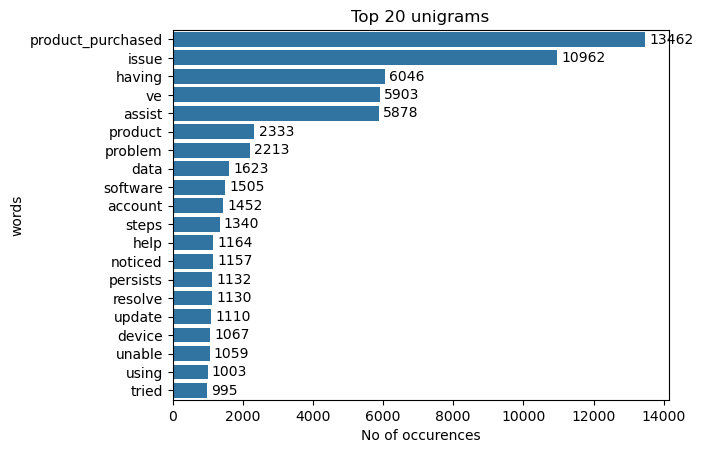

In [114]:
unigram_plot = sns.barplot(x=unigram_freq['Frequency'], y=unigram_freq.index)

unigram_plot.bar_label(unigram_plot.containers[0], fmt="%d", padding = 3)

plt.title("Top 20 unigrams")
plt.xlabel("No of occurences")
plt.ylabel("words")

#### bigram

In [115]:
bigram_vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english', max_features = 20)
bigram_matrix = bigram_vectorizer.fit_transform(df_descr['Ticket Description'])
bigram_vectorizer.vocabulary_

{'having issue': np.int64(1),
 'issue product_purchased': np.int64(3),
 'product_purchased assist': np.int64(6),
 've tried': np.int64(18),
 'troubleshooting steps': np.int64(13),
 'issue persists': np.int64(2),
 'works fine': np.int64(19),
 've noticed': np.int64(15),
 've checked': np.int64(14),
 'software updates': np.int64(11),
 'product_purchased account': np.int64(5),
 've performed': np.int64(16),
 'factory reset': np.int64(0),
 'reset product_purchased': np.int64(9),
 'resolve problem': np.int64(10),
 'problem didn': np.int64(4),
 've recently': np.int64(17),
 'product_purchased issue': np.int64(7),
 'soon possible': np.int64(12),
 'product_purchased screen': np.int64(8)}

In [116]:
bigram_freq = pd.DataFrame(
    bigram_matrix.sum(axis = 0).T,
    index = bigram_vectorizer.get_feature_names_out(),
    columns = ["Frequency"]
).sort_values(by="Frequency", ascending = False)

Text(0, 0.5, 'words')

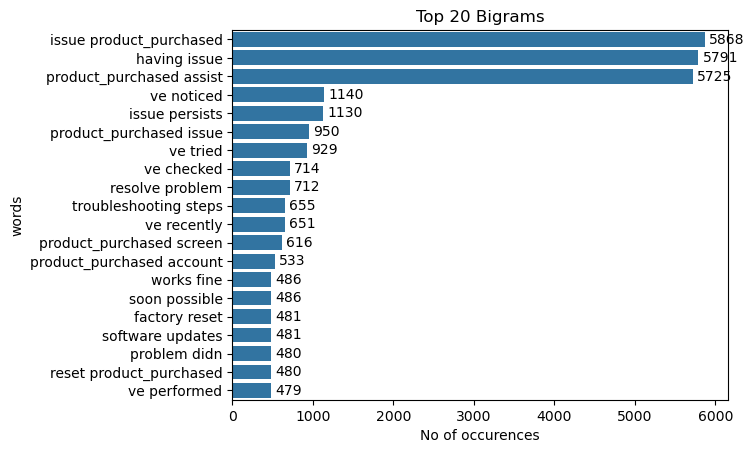

In [117]:
bigram_plot = sns.barplot(x=bigram_freq['Frequency'], y=bigram_freq.index)

bigram_plot.bar_label(bigram_plot.containers[0], fmt="%d", padding = 3)
plt.title("Top 20 Bigrams")
plt.xlabel("No of occurences")
plt.ylabel("words")

In [118]:
df_descr.to_csv('../data/customer_support_tickets_eda.csv', index = False)